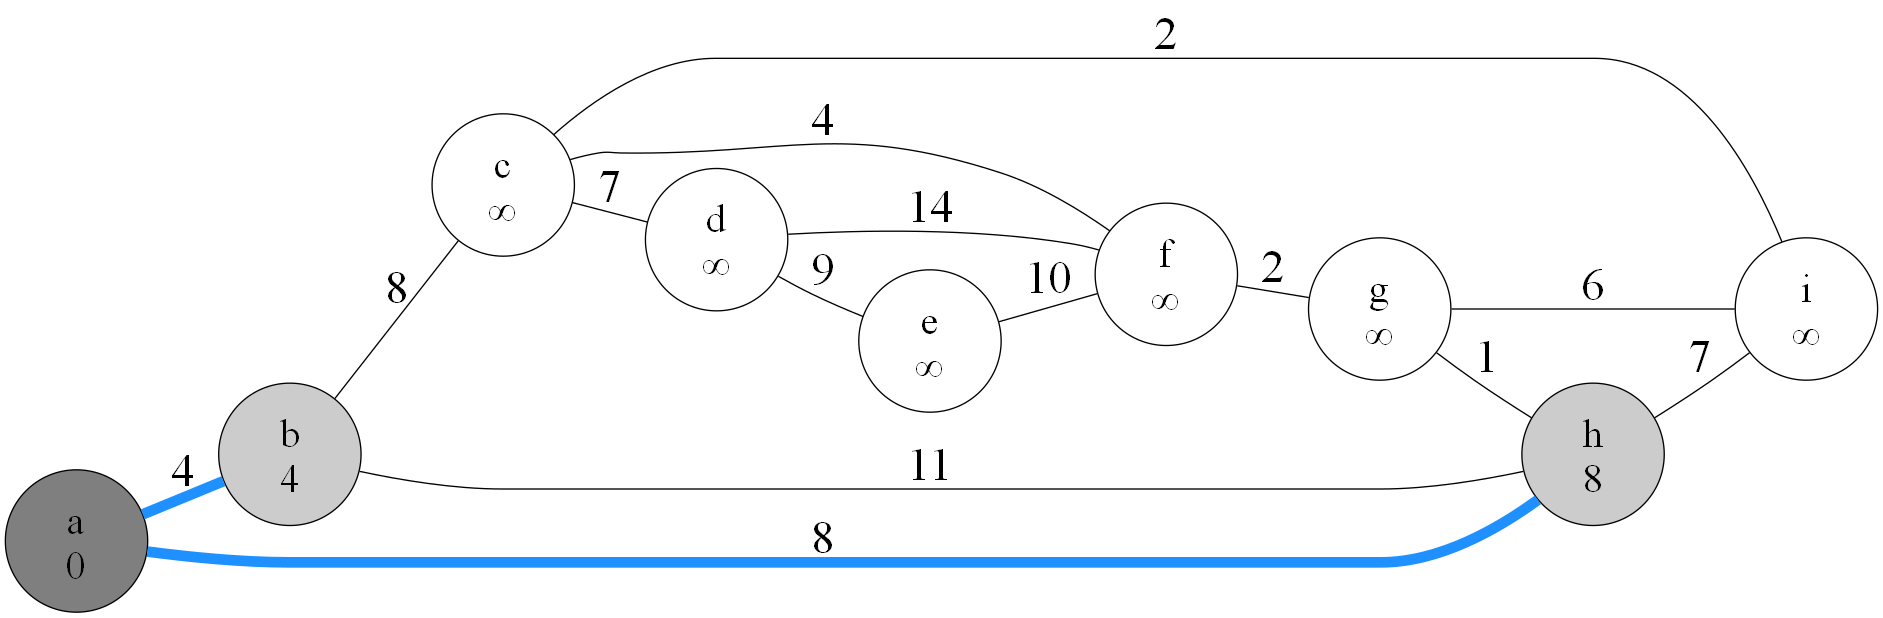

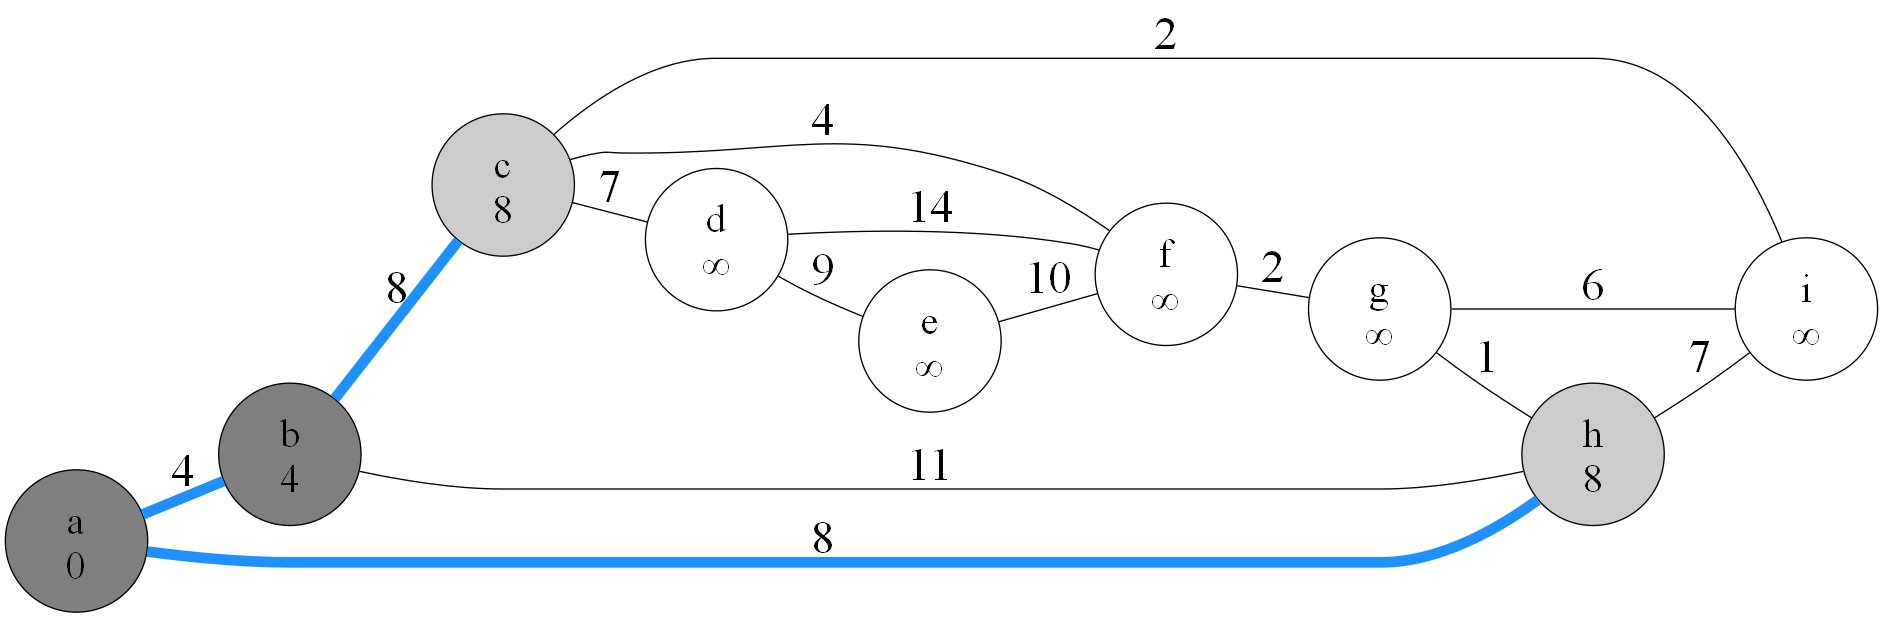

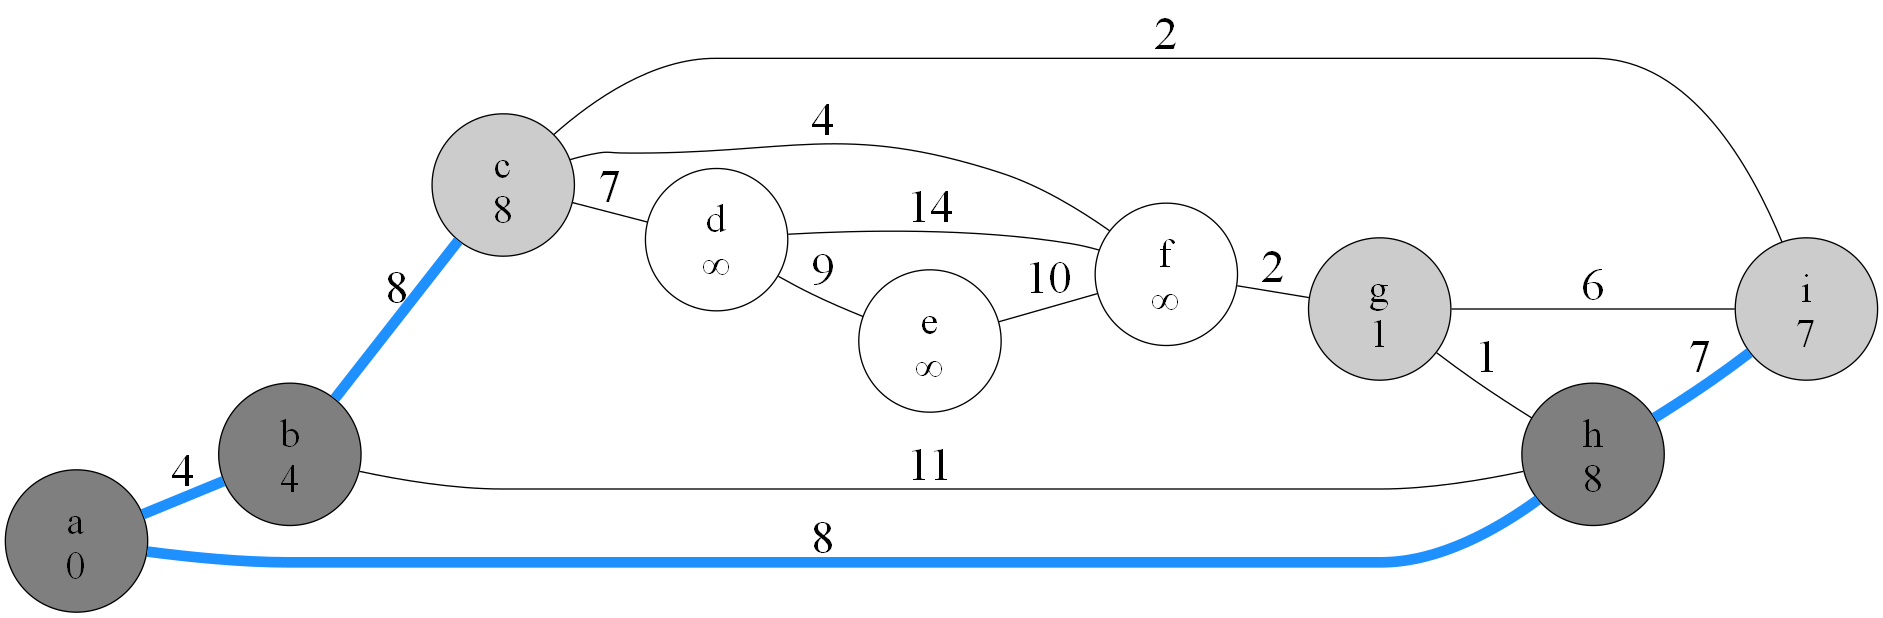

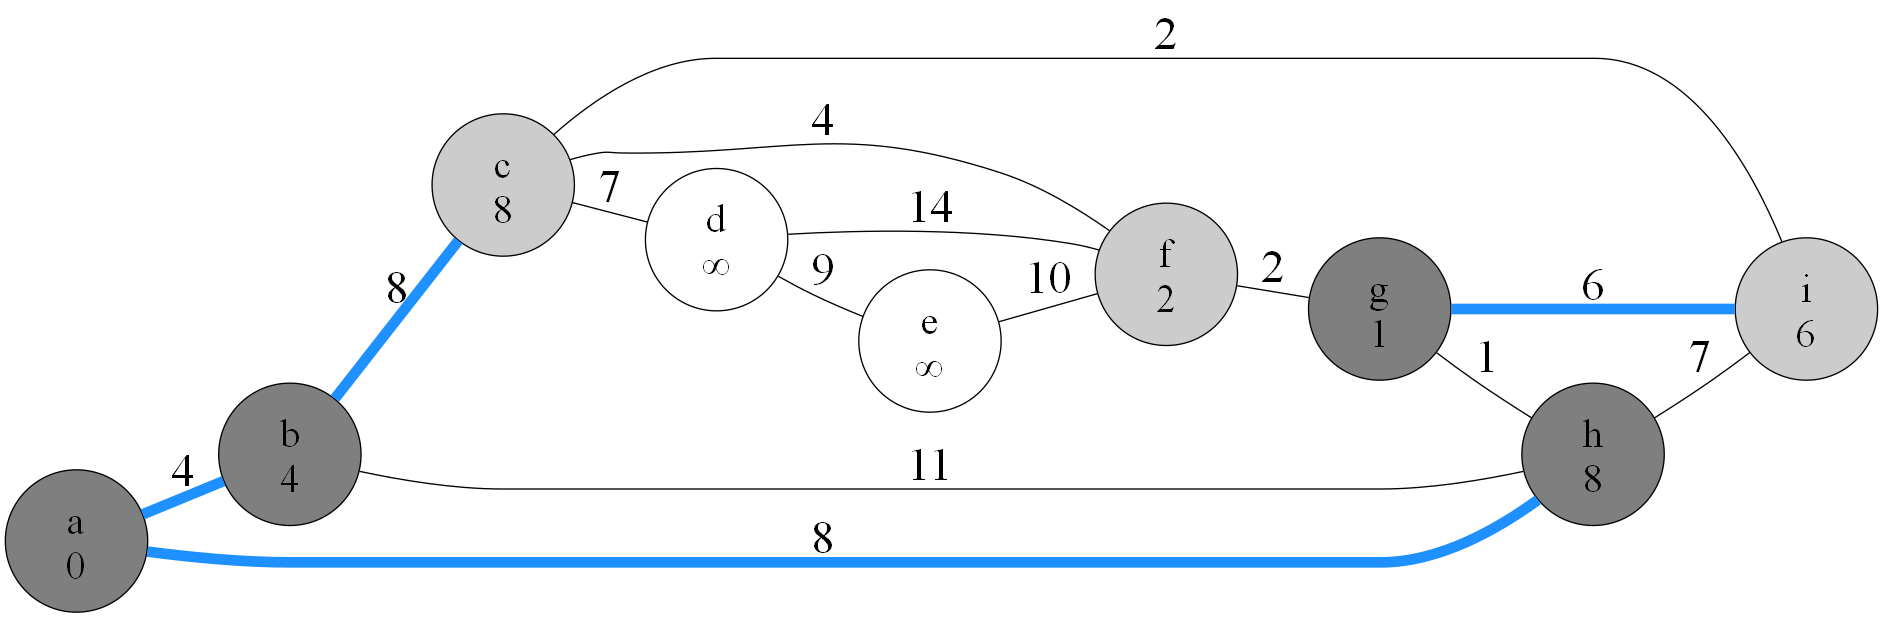

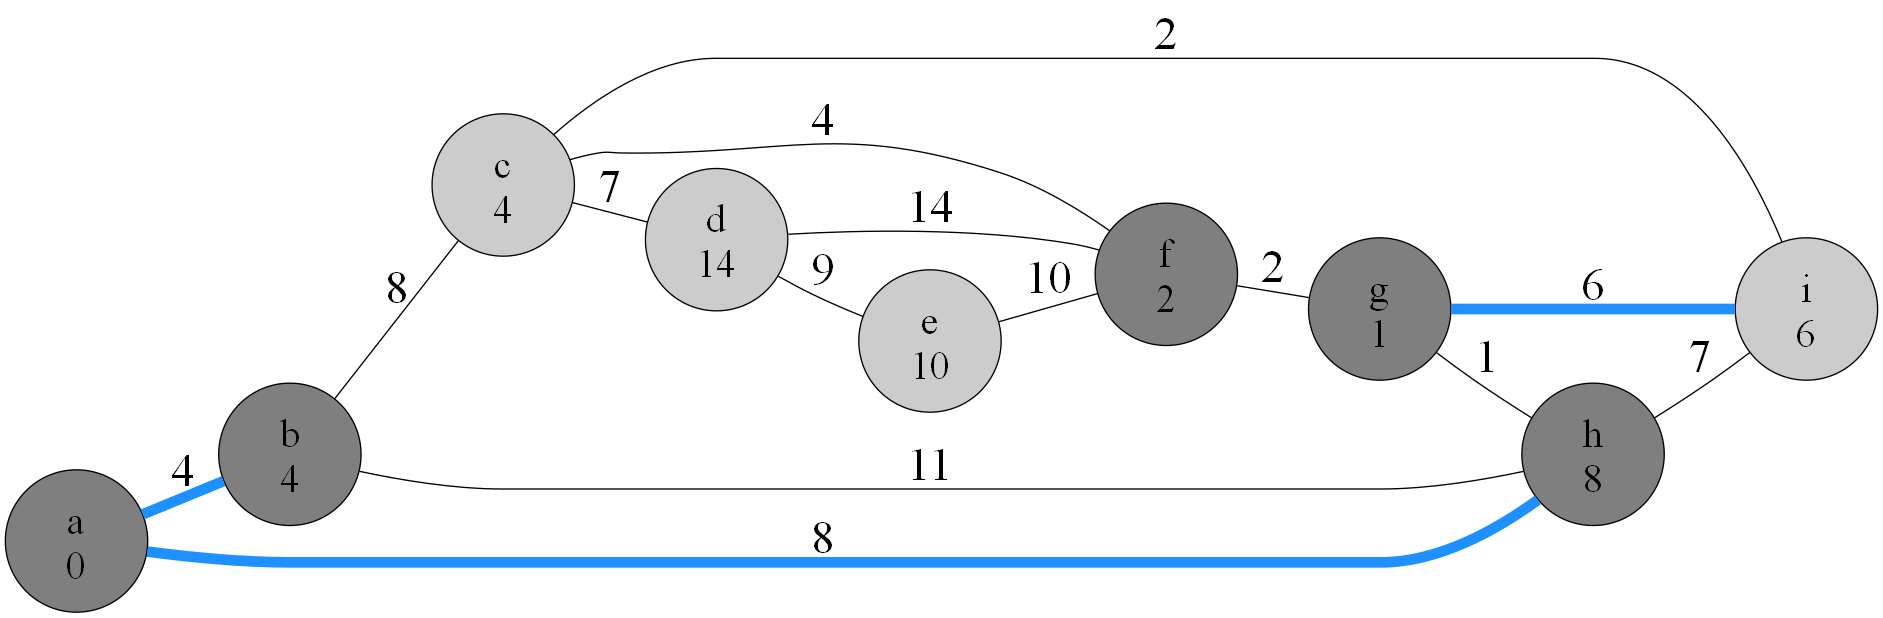

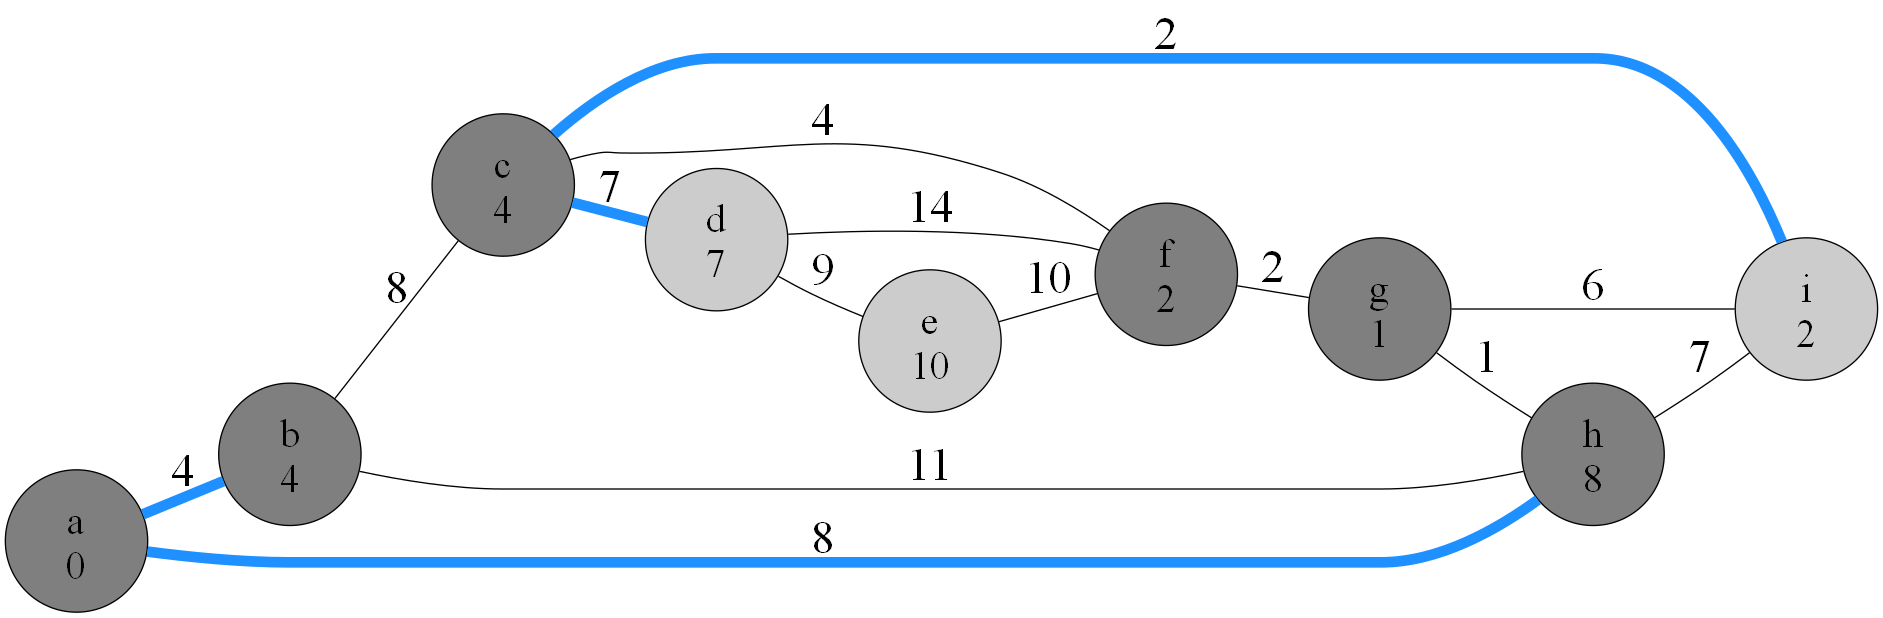

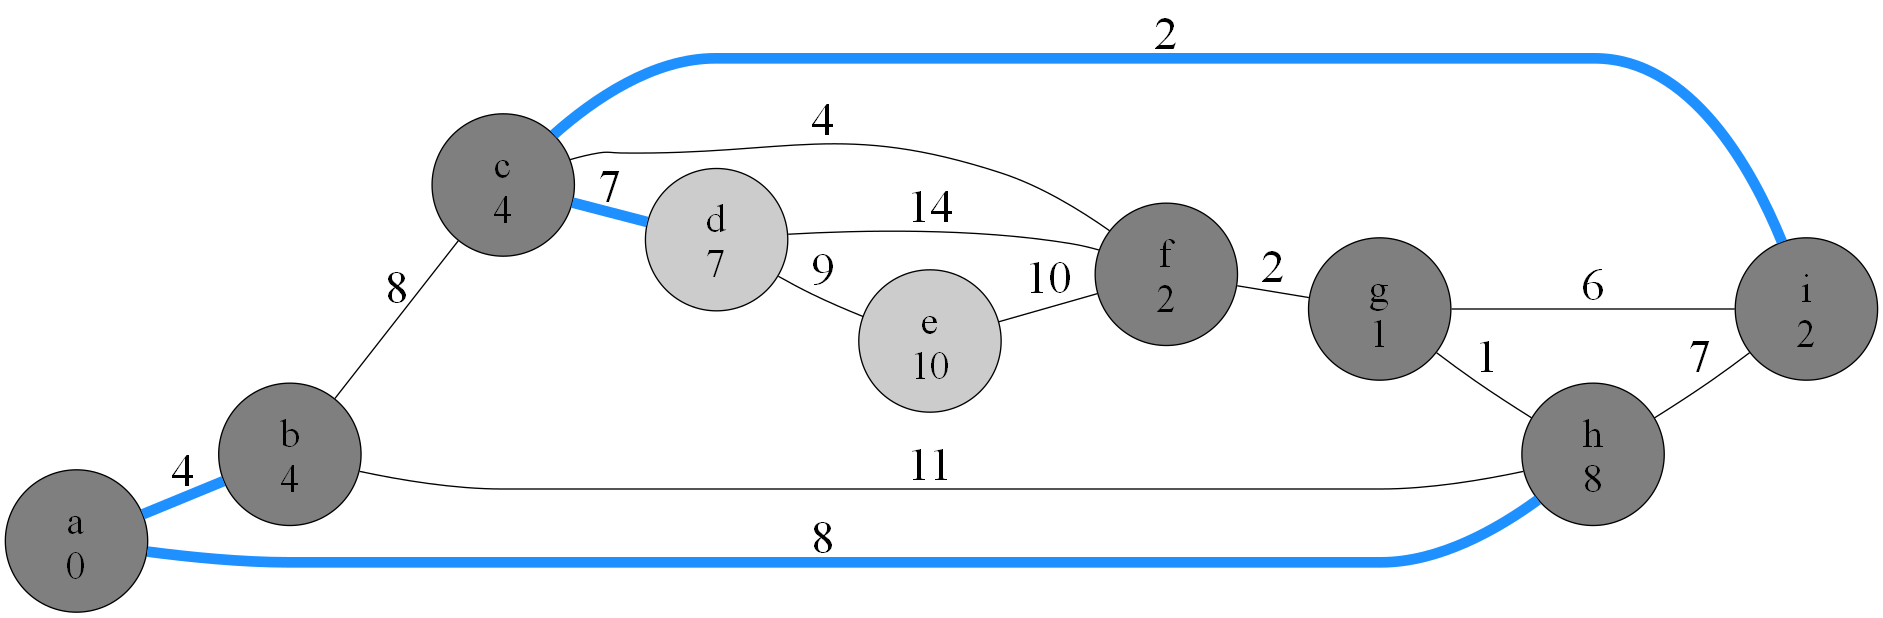

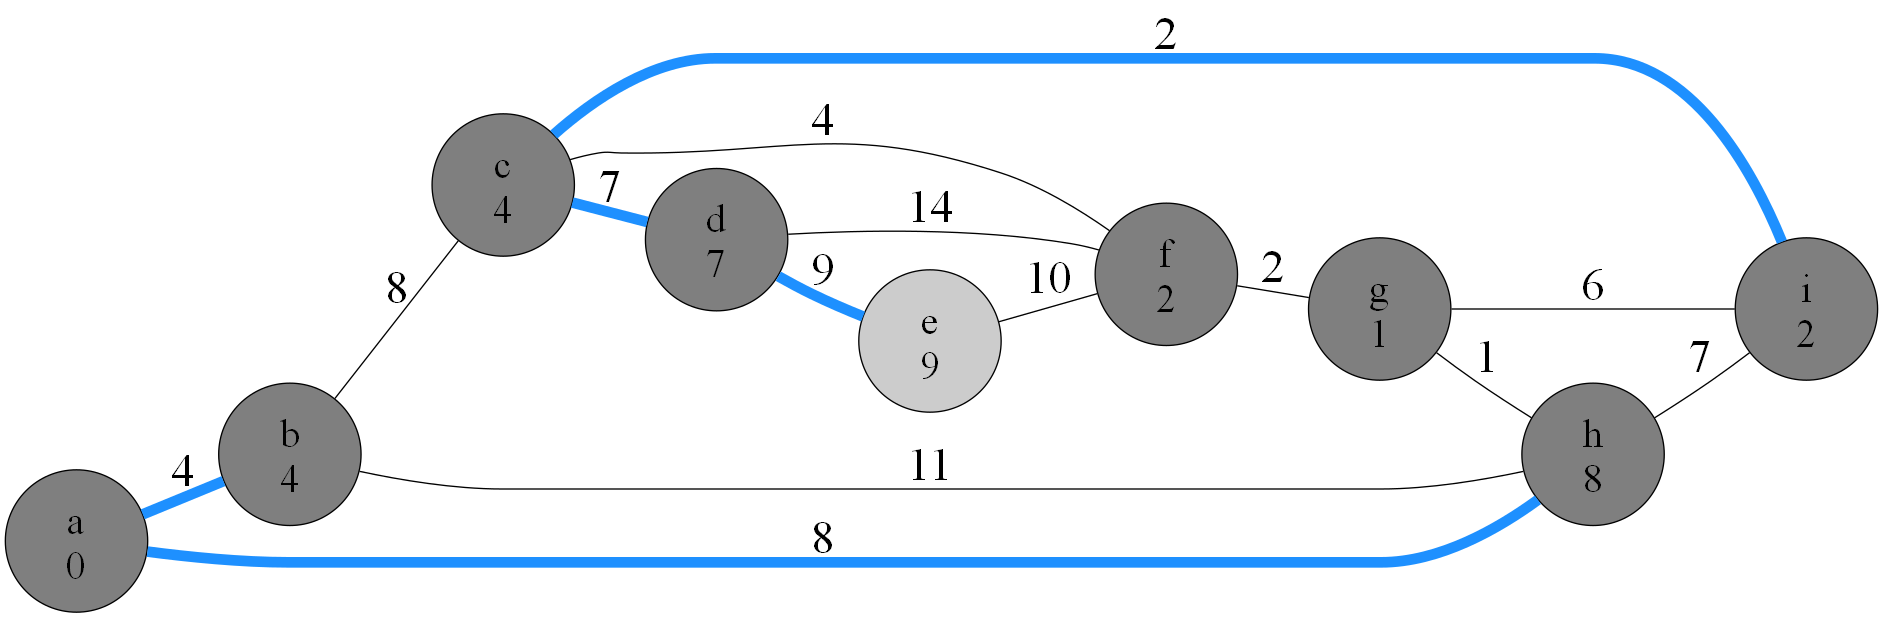

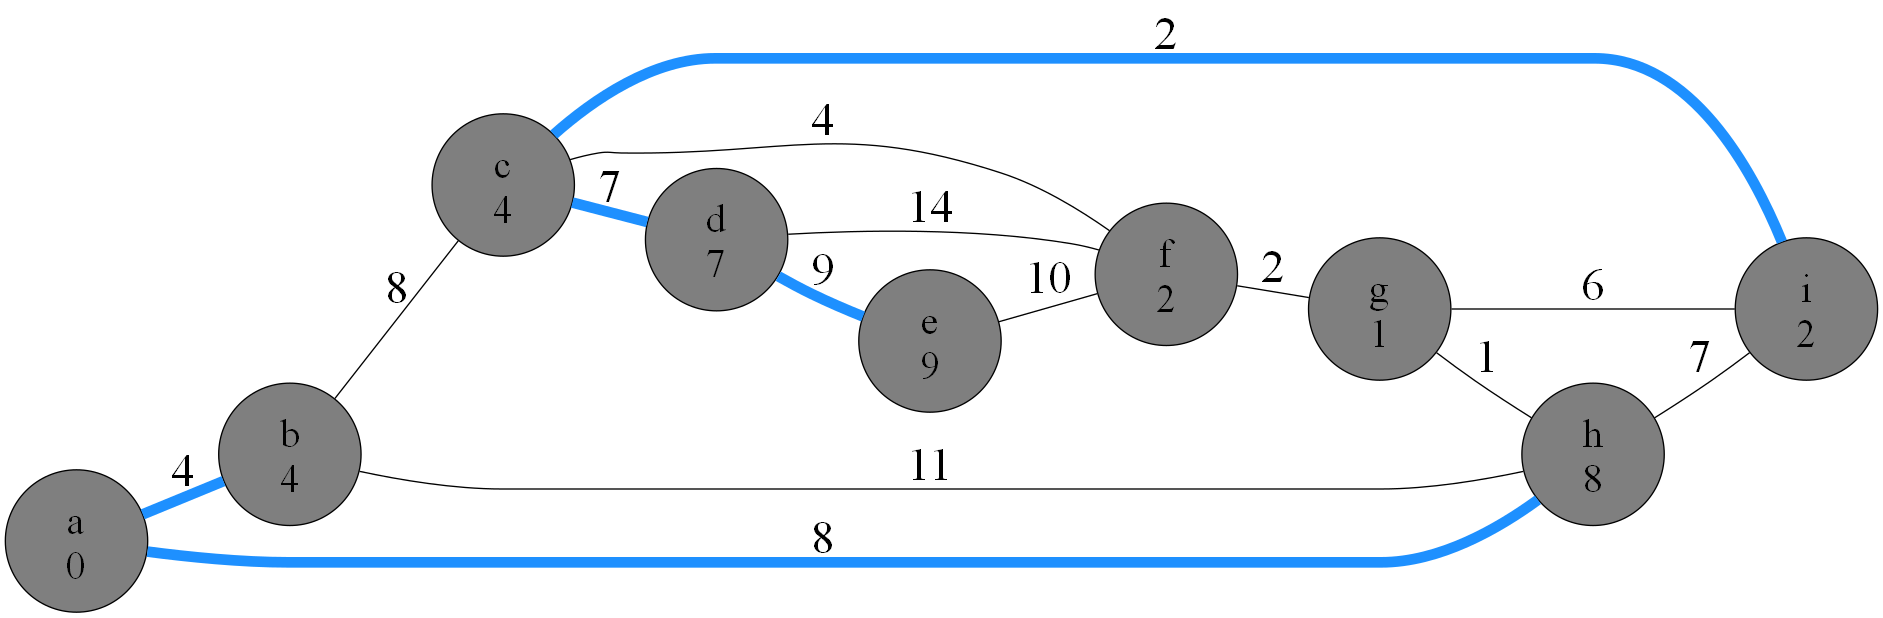

In [ ]:
import os
from graphviz import Graph
from IPython.display import Image, display


class Node:
    def __init__(self, name):
        # 保存最短路径
        self.par = None

        # Mini_Heap需要的属性
        self.d = float("inf")
        self.idx = None

        # Graph需要的属性
        self.name = name
        self.color = "white"


class Mini_Heap:
    def __init__(self, adj):
        self.heap = list(adj.keys())
        for idx, node in enumerate(self.heap):
            node.d = float("inf")
            node.idx = idx

    def __bool__(self):
        """判断堆是否为空 O(1)"""
        return bool(self.heap)

    def __contains__(self, node: Node):
        """判断结点是否在堆中 O(1)"""
        return node.idx != None

    def _heapify_down(self, idx):
        """向下调整最小堆 O(lgn)"""
        minI = idx
        size = len(self.heap)
        lchdI = 2 * idx + 1
        rchdI = 2 * idx + 2

        # 获取当前父子组最小结点
        if lchdI < size and self.heap[lchdI].d < self.heap[minI].d:
            minI = lchdI
        if rchdI < size and self.heap[rchdI].d < self.heap[minI].d:
            minI = rchdI

        if minI != idx:
            # 逐层上移更小结点, 并更新下标索引
            self.heap[minI], self.heap[idx] = self.heap[idx], self.heap[minI]
            self.heap[minI].idx, self.heap[idx].idx = minI, idx
            self._heapify_down(minI)

    def extract_min(self) -> Node:
        """从堆中取出最小值结点 O(lgn)"""
        size = len(self.heap)

        # 将末尾结点交换到堆顶, 并更新其下标索引
        self.heap[0], self.heap[size - 1] = self.heap[size - 1], self.heap[0]
        self.heap[0].idx, self.heap[size - 1].idx = 0, None

        # 弹出最小结点, 并自顶向下调整堆
        min_node = self.heap.pop()
        self._heapify_down(0)
        return min_node

    def _heapify_up(self, idx):
        """向上调整最小堆 O(lgn)"""
        if idx == 0:
            return
        parI = (idx - 1) // 2
        if self.heap[parI].d > self.heap[idx].d:
            # 逐层上移更小结点, 并更新下标索引
            self.heap[parI], self.heap[idx] = self.heap[idx], self.heap[parI]
            self.heap[parI].idx, self.heap[idx].idx = parI, idx
            self._heapify_up(parI)

    def decrease_key(self, node: Node, d: int):
        """减小堆中结点的值 O(lgn)"""
        node.d = d
        self._heapify_up(node.idx)


def draw(adj):
    dot = Graph()
    dot.attr(rankdir="LR")
    dot.attr("node", shape="circle", fontsize="30")
    dot.attr("edge", fontsize="35")
    edges = set()
    for u in adj:
        dot.node(u.name, f"{u.name}\n{"∞" if u.d == float('inf') else u.d}", style="filled", fillcolor=u.color)
        for v, cost in adj[u]:
            if (v, u) in edges:
                continue
            edges.add((u, v))
            if v.par == u:
                dot.edge(u.name, v.name, label=str(cost), color="dodgerblue", penwidth="8")
            else:
                dot.edge(u.name, v.name, label=str(cost))
    dot.render("demo", format="png", cleanup=True)
    display(Image("demo.png"))
    os.remove("demo.png")


def MST_PRIM(adj):
    # 初始化 父结点列表, 优先队列
    Q = Mini_Heap(adj)
    Q.decrease_key(list(adj.keys())[0], 0)  # O(lgV)

    # 获取当前的最小可连结点 [V]
    while Q:
        u = Q.extract_min()  # O(lgV)
        u.color = "gray50"
        # 更新相邻的未记结点值 [E]
        for v, cost in adj[u]:
            if v in Q and v.d > cost:
                Q.decrease_key(v, cost)  # O(lgV)
                v.par = u
                v.color = "gray80"
        draw(adj)


E = [(0, 1, 4), (0, 7, 8), (1, 2, 8), (1, 7, 11), (2, 3, 7), (2, 8, 2), (2, 5, 4), (3, 4, 9), (3, 5, 14), (4, 5, 10), (5, 6, 2), (6, 7, 1), (6, 8, 6), (7, 8, 7)]
idx2node = [Node(x) for x in "abcdefghi"]
adj = {idx2node[i]: [] for i in range(len(idx2node))}
for u, v, cost in E:
    nu, nv = idx2node[u], idx2node[v]
    adj[nu].append((nv, cost))
    adj[nv].append((nu, cost))
MST_PRIM(adj)